# 011 - Full EDA for Order Book Microstructure (BTC-USDT-SWAP)

Этот ноутбук делает полный EDA на reconstructed order book snapshots (100ms) и ориентирован на практические HFT-инсайты.

## Sections
1. Data Preparation + Quality Report
2. Basic Market Stats
3. Order Book Shape
4. Order Book Imbalance
5. Microprice
6. Short-term Returns
7. Imbalance Predictive Power
8. Spread Regime Analysis
9. Intraday Patterns
10. Optional: Liquidity Shocks & Imbalance Spikes

In [18]:
import sys
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Root detection (works from repo root and notebooks/*)
candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]
root = next((p for p in candidates if (p / "pyproject.toml").exists()), Path.cwd())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

print("root:", root)

root: d:\tumar\okx-hft-research


In [19]:
# CONFIG
INST_ID = "BTC-USDT-SWAP"
MODE_DIR = root / "data" / "reconstructed" / INST_ID / "grid100ms"

# Range [START, END]
START = "2026-03-23 00:00:00"
END = "2026-03-25 23:59:59"

# Performance knobs
PLOT_SAMPLE_N = 200_000
DEPTH_PROFILE_SAMPLE_N = 1_000
RET_HORIZONS = {"ret_100ms": 1, "ret_1s": 10, "ret_5s": 50}
IMB_FWD_RET_STEPS = 10  # 1 second ahead at 100ms frequency
IMB_Q_BINS = 10

start_ts = pd.Timestamp(START, tz="UTC")
end_ts = pd.Timestamp(END, tz="UTC")
if end_ts < start_ts:
    raise ValueError("END must be >= START")

bid_sz_cols = [f"bid_sz_{i:02d}" for i in range(1, 11)]
ask_sz_cols = [f"ask_sz_{i:02d}" for i in range(1, 11)]
bid_px_cols = [f"bid_px_{i:02d}" for i in range(1, 11)]
ask_px_cols = [f"ask_px_{i:02d}" for i in range(1, 11)]

print("INST_ID:", INST_ID)
print("RANGE :", start_ts, "..", end_ts)
print("MODE_DIR:", MODE_DIR)

INST_ID: BTC-USDT-SWAP
RANGE : 2026-03-23 00:00:00+00:00 .. 2026-03-25 23:59:59+00:00
MODE_DIR: d:\tumar\okx-hft-research\data\reconstructed\BTC-USDT-SWAP\grid100ms


In [20]:
# Load and merge all parquet files that overlap [START, END]
if not MODE_DIR.exists():
    raise FileNotFoundError(f"Folder not found: {MODE_DIR}")

pattern = re.compile(
    rf"^book_grid100ms_{re.escape(INST_ID)}_(\d{{4}}-\d{{2}}-\d{{2}})_(\d{{2}}-\d{{2}}-\d{{2}})__(\d{{4}}-\d{{2}}-\d{{2}})_(\d{{2}}-\d{{2}}-\d{{2}})$"
)

selected = []
for p in sorted(MODE_DIR.rglob(f"book_grid100ms_{INST_ID}_*.parquet")):
    m = pattern.match(p.stem)
    if not m:
        continue

    s_date, s_time, e_date, e_time = m.groups()
    file_start = pd.Timestamp(f"{s_date} {s_time.replace('-', ':')}", tz="UTC")
    file_end = pd.Timestamp(f"{e_date} {e_time.replace('-', ':')}", tz="UTC")

    # overlap check
    if file_end >= start_ts and file_start <= end_ts:
        selected.append((file_start, p))

if not selected:
    raise FileNotFoundError(
        f"No parquet files overlap with range [{start_ts} .. {end_ts}] under {MODE_DIR}"
    )

selected = [p for _, p in sorted(selected, key=lambda x: x[0])]
print(f"Selected parquet files: {len(selected)}")
for p in selected[:5]:
    print(" -", p)
if len(selected) > 5:
    print(f" ... and {len(selected) - 5} more")

df = pd.concat([pd.read_parquet(p) for p in selected], ignore_index=True)
if "ts_event" in df.columns:
    df["ts_event"] = pd.to_datetime(df["ts_event"], utc=True, errors="coerce")
    df = df[(df["ts_event"] >= start_ts) & (df["ts_event"] <= end_ts)].copy()
    df = df.sort_values("ts_event").reset_index(drop=True)

print("Merged rows:", len(df))
display(df.head())

Selected parquet files: 72
 - d:\tumar\okx-hft-research\data\reconstructed\BTC-USDT-SWAP\grid100ms\2026-03-23\book_grid100ms_BTC-USDT-SWAP_2026-03-23_00-00-00__2026-03-23_01-00-00.parquet
 - d:\tumar\okx-hft-research\data\reconstructed\BTC-USDT-SWAP\grid100ms\2026-03-23\book_grid100ms_BTC-USDT-SWAP_2026-03-23_01-00-00__2026-03-23_02-00-00.parquet
 - d:\tumar\okx-hft-research\data\reconstructed\BTC-USDT-SWAP\grid100ms\2026-03-23\book_grid100ms_BTC-USDT-SWAP_2026-03-23_02-00-00__2026-03-23_03-00-00.parquet
 - d:\tumar\okx-hft-research\data\reconstructed\BTC-USDT-SWAP\grid100ms\2026-03-23\book_grid100ms_BTC-USDT-SWAP_2026-03-23_03-00-00__2026-03-23_04-00-00.parquet
 - d:\tumar\okx-hft-research\data\reconstructed\BTC-USDT-SWAP\grid100ms\2026-03-23\book_grid100ms_BTC-USDT-SWAP_2026-03-23_04-00-00__2026-03-23_05-00-00.parquet
 ... and 67 more


Merged rows: 2592062


,ts_event,inst_id,anchor_snapshot_ts,reconstruction_mode,mid_px,spread_px,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,bid_px_03,bid_sz_03,bid_px_04,bid_sz_04,bid_px_05,bid_sz_05,bid_px_06,bid_sz_06,bid_px_07,bid_sz_07,bid_px_08,bid_sz_08,bid_px_09,bid_sz_09,bid_px_10,bid_sz_10,ask_px_01,ask_sz_01,ask_px_02,ask_sz_02,ask_px_03,ask_sz_03,ask_px_04,ask_sz_04,ask_px_05,ask_sz_05,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09,ask_px_10,ask_sz_10
0,2026-03-23 00:00:00+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67830.85,0.1,67830.8,456.44,67830.7,0.43,67830.6,0.05,67830.4,0.05,67830.3,0.06,67830.2,0.05,67830.1,0.02,67830.0,22.07,67829.9,0.05,67829.8,0.05,67830.9,1006.90,67831.0,5.01,67831.3,0.01,67831.4,33.71,67831.5,5.00,67831.6,0.75,67831.7,13.78,67831.8,0.02,67831.9,70.47,67832.1,0.05
1,2026-03-23 00:00:00.100000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67830.85,0.1,67830.8,466.58,67830.7,0.43,67830.6,0.05,67830.4,0.05,67830.3,0.06,67830.2,0.05,67830.1,0.02,67830.0,22.07,67829.9,0.05,67829.8,0.05,67830.9,934.90,67831.0,5.01,67831.3,32.12,67831.4,33.71,67831.5,5.00,67831.8,0.03,67831.9,70.47,67832.1,0.05,67832.2,0.06,67832.3,22.34
2,2026-03-23 00:00:00.200000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67830.85,0.1,67830.8,488.05,67830.7,0.43,67830.6,0.05,67830.4,0.05,67830.3,0.06,67830.2,0.05,67830.1,0.02,67830.0,30.65,67829.9,0.05,67829.8,0.05,67830.9,3.03,67831.0,5.01,67831.3,0.01,67831.4,0.01,67831.5,5.00,67831.9,0.05,67832.1,0.05,67832.2,0.05,67832.3,0.06,67832.4,0.03
3,2026-03-23 00:00:00.300000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67840.65,0.1,67840.6,1032.91,67840.5,8.02,67840.2,0.01,67839.2,0.01,67839.1,0.06,67839.0,18.00,67838.5,0.05,67838.4,0.02,67838.3,0.01,67838.1,87.74,67840.7,198.08,67840.8,0.03,67841.1,0.01,67841.5,0.13,67841.8,0.01,67842.1,0.03,67842.2,0.01,67842.7,0.04,67842.8,0.90,67843.1,0.01
4,2026-03-23 00:00:00.400000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67843.85,0.1,67843.8,914.75,67843.7,0.01,67843.6,0.01,67842.4,0.01,67842.3,0.03,67841.7,0.03,67841.1,0.05,67841.0,0.86,67840.8,0.02,67840.7,27.60,67843.9,458.60,67844.0,0.01,67844.3,125.58,67844.4,176.06,67844.5,0.01,67844.6,0.01,67845.1,0.03,67845.3,0.01,67845.4,0.33,67845.6,0.01


In [21]:
# 1) Data Preparation + Quality Report

# Ensure datetime, sort, set index
if "ts_event" not in df.columns:
    raise ValueError("Expected column ts_event in reconstructed parquet")

work_df = df.copy()
work_df["ts_event"] = pd.to_datetime(work_df["ts_event"], utc=True, errors="coerce")
work_df = work_df.dropna(subset=["ts_event"]).sort_values("ts_event").reset_index(drop=True)

# Duplicates
dup_ts_count = int(work_df["ts_event"].duplicated().sum())
full_dup_count = int(work_df.duplicated().sum())

# Missing values (top-level key fields)
key_cols = ["mid_px", "spread_px", "bid_px_01", "ask_px_01", "bid_sz_01", "ask_sz_01"]
missing_key = work_df[key_cols].isna().sum().to_dict()

# Invalid states
neg_sizes_count = int((work_df[bid_sz_cols + ask_sz_cols] < 0).sum().sum())
crossed_book_count = int((work_df["bid_px_01"] >= work_df["ask_px_01"]).fillna(False).sum())

quality_report = {
    "rows": int(len(work_df)),
    "columns": len(work_df.columns),
    "ts_event_min": work_df["ts_event"].min(),
    "ts_event_max": work_df["ts_event"].max(),
    "duplicate_ts_event_rows": dup_ts_count,
    "full_duplicate_rows": full_dup_count,
    "negative_sizes_total": neg_sizes_count,
    "crossed_book_rows_bid_ge_ask": crossed_book_count,
    "missing_key_columns": missing_key,
}

display(pd.DataFrame([quality_report]).T.rename(columns={0: "value"}))

# Use ts_event as index for time-series operations
work_df = work_df.set_index("ts_event").sort_index()
print("Index set to ts_event. Final rows:", len(work_df))

,value
rows,2592062
columns,46
ts_event_min,2026-03-23 00:00:00+00:00
ts_event_max,2026-03-25 23:59:59+00:00
duplicate_ts_event_rows,71
full_duplicate_rows,71
negative_sizes_total,0
crossed_book_rows_bid_ge_ask,0
missing_key_columns,"{'mid_px': 0, 'spread_px': 0, 'bid_px_01': 0, ..."


Index set to ts_event. Final rows: 2592062


,value
mid_mean,70338.211979
mid_std,1041.823592
spread_mean,0.101464
spread_p50,0.100000
spread_p95,0.100000
spread_bps_mean,0.014428
spread_bps_p95,0.014690


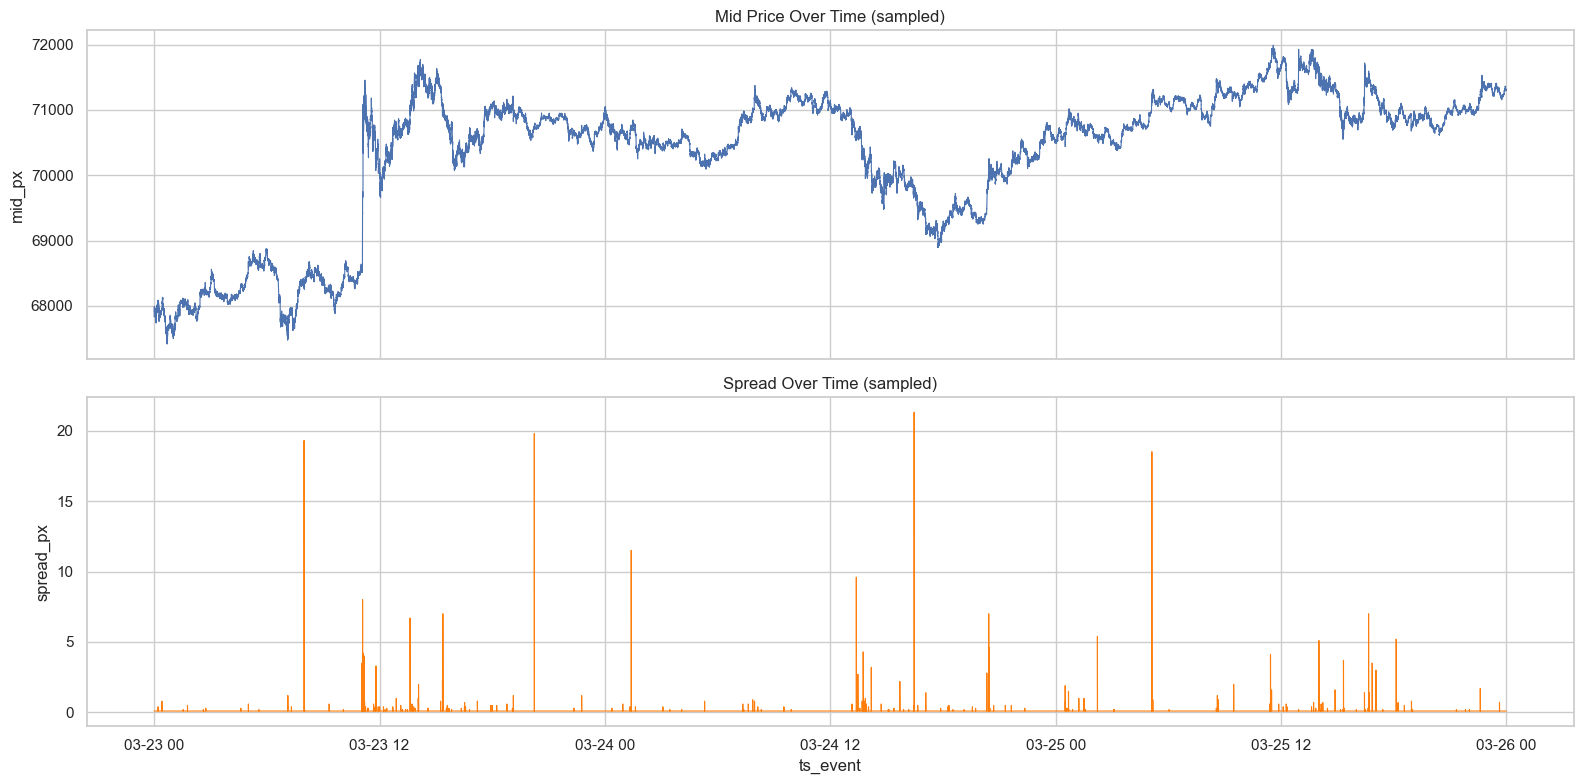

In [22]:
# 2) Basic Market Stats

market_stats = {
    "mid_mean": float(work_df["mid_px"].mean()),
    "mid_std": float(work_df["mid_px"].std()),
    "spread_mean": float(work_df["spread_px"].mean()),
    "spread_p50": float(work_df["spread_px"].quantile(0.50)),
    "spread_p95": float(work_df["spread_px"].quantile(0.95)),
}
work_df["spread_bps"] = (work_df["spread_px"] / work_df["mid_px"]).replace([np.inf, -np.inf], np.nan) * 10_000
market_stats["spread_bps_mean"] = float(work_df["spread_bps"].mean())
market_stats["spread_bps_p95"] = float(work_df["spread_bps"].quantile(0.95))

display(pd.DataFrame([market_stats]).T.rename(columns={0: "value"}))

# Plot on sampled points for performance
plot_df = work_df.reset_index()
if len(plot_df) > PLOT_SAMPLE_N:
    step = max(1, len(plot_df) // PLOT_SAMPLE_N)
    plot_df = plot_df.iloc[::step].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(plot_df["ts_event"], plot_df["mid_px"], linewidth=0.8)
axes[0].set_title("Mid Price Over Time (sampled)")
axes[0].set_ylabel("mid_px")

axes[1].plot(plot_df["ts_event"], plot_df["spread_px"], linewidth=0.8, color="tab:orange")
axes[1].set_title("Spread Over Time (sampled)")
axes[1].set_ylabel("spread_px")
axes[1].set_xlabel("ts_event")
plt.tight_layout()
plt.show()

## 3) Order Book Shape

Почему важно: форма глубины показывает реальную доступную ликвидность для агрессивного исполнения и риск проскальзывания.

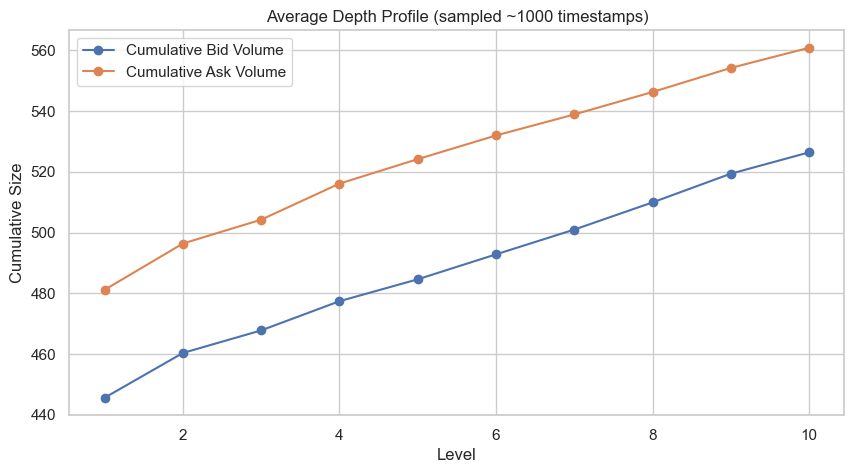

In [23]:
shape_df = work_df.reset_index()
if len(shape_df) > DEPTH_PROFILE_SAMPLE_N:
    shape_df = shape_df.sample(DEPTH_PROFILE_SAMPLE_N, random_state=42)

avg_bid_sz = shape_df[bid_sz_cols].mean()
avg_ask_sz = shape_df[ask_sz_cols].mean()

cum_bid = avg_bid_sz.cumsum().to_numpy()
cum_ask = avg_ask_sz.cumsum().to_numpy()
levels = np.arange(1, 11)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(levels, cum_bid, marker="o", label="Cumulative Bid Volume")
ax.plot(levels, cum_ask, marker="o", label="Cumulative Ask Volume")
ax.set_title("Average Depth Profile (sampled ~1000 timestamps)")
ax.set_xlabel("Level")
ax.set_ylabel("Cumulative Size")
ax.legend()
plt.show()

## 4) Order Book Imbalance

Почему важно: imbalance часто прокси краткосрочного давления спроса/предложения.

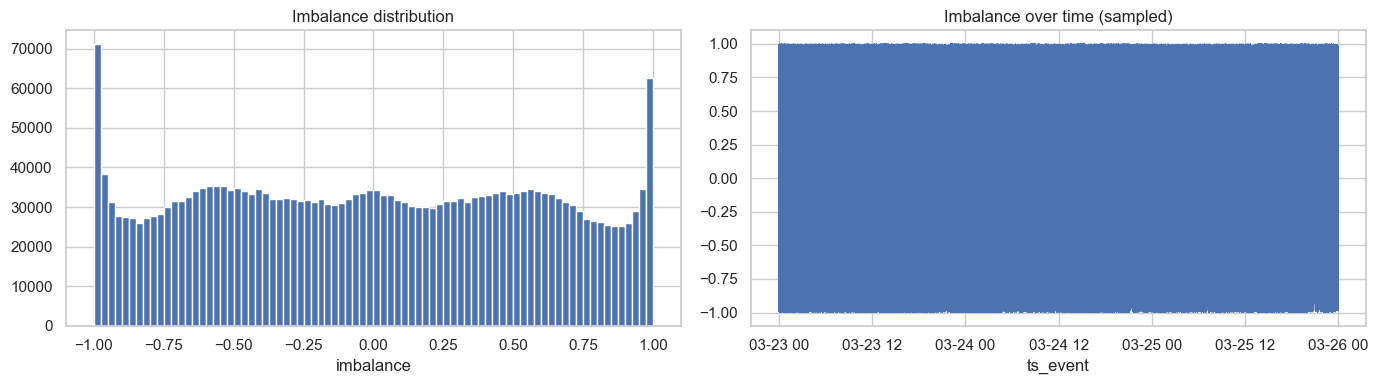

In [24]:
bid_sum = work_df[bid_sz_cols].sum(axis=1)
ask_sum = work_df[ask_sz_cols].sum(axis=1)
den = (bid_sum + ask_sum).replace(0, np.nan)
work_df["imbalance"] = (bid_sum - ask_sum) / den

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(work_df["imbalance"].dropna(), bins=80)
axes[0].set_title("Imbalance distribution")
axes[0].set_xlabel("imbalance")

sample_imb = work_df[["imbalance"]].dropna().reset_index()
if len(sample_imb) > PLOT_SAMPLE_N:
    step = max(1, len(sample_imb) // PLOT_SAMPLE_N)
    sample_imb = sample_imb.iloc[::step].copy()
axes[1].plot(sample_imb["ts_event"], sample_imb["imbalance"], linewidth=0.7)
axes[1].set_title("Imbalance over time (sampled)")
axes[1].set_xlabel("ts_event")
plt.tight_layout()
plt.show()

## 5) Microprice

Почему важно: microprice учитывает дисбаланс объёмов на best bid/ask и часто лучше отражает короткий дрейф, чем mid.

,count,mean,std,min,50%,95%,max
mid_px,2592062.0,70338.211979,1041.823592,67417.050000,70702.550000,71440.450000,71988.950000
microprice,2592062.0,70338.211441,1041.823356,67417.009787,70702.532607,71440.421702,71988.959063
micro_minus_mid_bps,2592062.0,-0.000076,0.007616,-3.229025,-0.000089,0.006575,2.460907


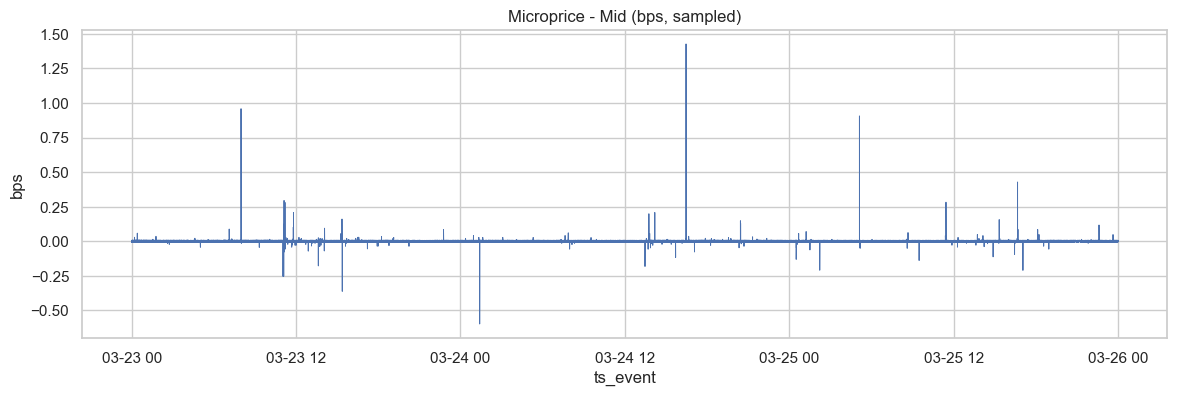

In [25]:
den_micro = (work_df["bid_sz_01"] + work_df["ask_sz_01"]).replace(0, np.nan)
work_df["microprice"] = (
    work_df["bid_px_01"] * work_df["ask_sz_01"] +
    work_df["ask_px_01"] * work_df["bid_sz_01"]
) / den_micro
work_df["micro_minus_mid_bps"] = ((work_df["microprice"] - work_df["mid_px"]) / work_df["mid_px"]) * 10_000

display(work_df[["mid_px", "microprice", "micro_minus_mid_bps"]].describe(percentiles=[0.5, 0.95]).T)

mm = work_df[["micro_minus_mid_bps"]].dropna().reset_index()
if len(mm) > PLOT_SAMPLE_N:
    step = max(1, len(mm) // PLOT_SAMPLE_N)
    mm = mm.iloc[::step].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(mm["ts_event"], mm["micro_minus_mid_bps"], linewidth=0.7)
ax.set_title("Microprice - Mid (bps, sampled)")
ax.set_xlabel("ts_event")
ax.set_ylabel("bps")
plt.show()

## 6) Short-term Returns (100ms, 1s, 5s)

Почему важно: распределение и волатильность коротких доходностей определяют реалистичность alpha и риск-менеджмент.

,mean,std,p01,p50,p99
ret_100ms,1.965813e-08,0.000027,-0.000089,0.0,0.000088
ret_1s,1.969431e-07,0.000096,-0.000271,0.0,0.000277
ret_5s,9.853022e-07,0.000226,-0.000586,0.0,0.000605


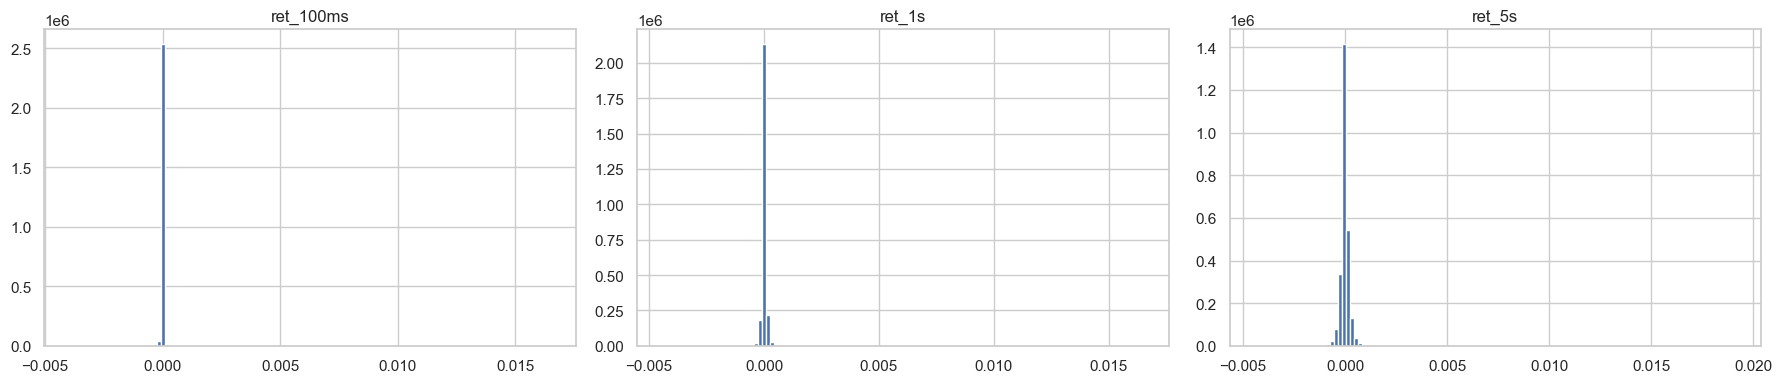

In [26]:
for name, steps in RET_HORIZONS.items():
    work_df[name] = work_df["mid_px"].shift(-steps) / work_df["mid_px"] - 1.0

ret_stats = {}
for name in RET_HORIZONS:
    s = work_df[name].dropna()
    ret_stats[name] = {
        "mean": float(s.mean()),
        "std": float(s.std()),
        "p01": float(s.quantile(0.01)),
        "p50": float(s.quantile(0.50)),
        "p99": float(s.quantile(0.99)),
    }

display(pd.DataFrame(ret_stats).T)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, name in zip(axes, RET_HORIZONS.keys()):
    ax.hist(work_df[name].dropna(), bins=120)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 7) Imbalance Predictive Power (imbalance -> future 1s return)

Почему важно: проверка монотонности `imbalance` по future return — базовый тест сигналоспособности.

,imb_bin,future_ret_1s
0,"(-1.001, -0.815]",-0.000040
1,"(-0.815, -0.606]",-0.000019
2,"(-0.606, -0.419]",-0.000011
3,"(-0.419, -0.219]",-0.000006
4,"(-0.219, -0.0157]",-0.000003
5,"(-0.0157, 0.186]",0.000003
6,"(0.186, 0.392]",0.000006
7,"(0.392, 0.585]",0.000012
8,"(0.585, 0.795]",0.000019
9,"(0.795, 1.0]",0.000040


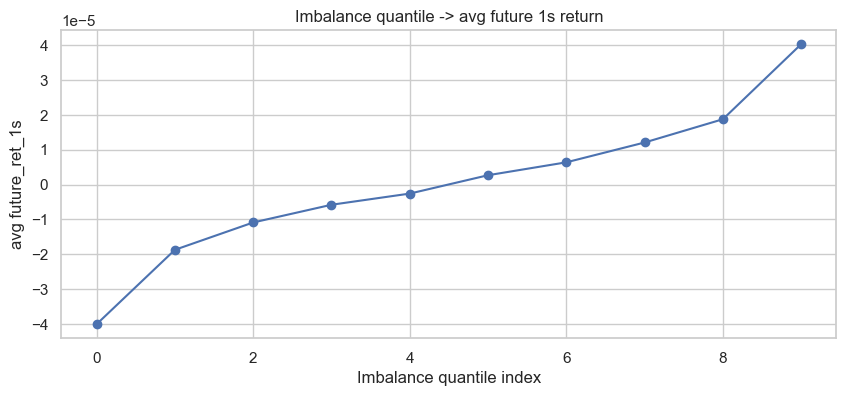

In [27]:
work_df["future_ret_1s"] = work_df["mid_px"].shift(-IMB_FWD_RET_STEPS) / work_df["mid_px"] - 1.0

sig_df = work_df[["imbalance", "future_ret_1s"]].replace([np.inf, -np.inf], np.nan).dropna()
sig_df = sig_df.loc[sig_df["imbalance"].between(-1, 1)]

# qcut can fail on too many identical values; use duplicates='drop'
sig_df["imb_bin"] = pd.qcut(sig_df["imbalance"], q=IMB_Q_BINS, duplicates="drop")
imb_ret = sig_df.groupby("imb_bin", observed=True)["future_ret_1s"].mean().reset_index()

display(imb_ret)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(len(imb_ret)), imb_ret["future_ret_1s"], marker="o")
ax.set_title("Imbalance quantile -> avg future 1s return")
ax.set_xlabel("Imbalance quantile index")
ax.set_ylabel("avg future_ret_1s")
plt.show()

## 8) Spread Regime Analysis (tight vs wide)

Почему важно: стратегия и риск ведут себя по-разному при узком/широком спреде.

In [28]:
# Define regimes by median spread_bps
spread_med = work_df["spread_bps"].median()
work_df["spread_regime"] = np.where(work_df["spread_bps"] <= spread_med, "tight", "wide")

regime_stats = (
    work_df
    .groupby("spread_regime")
    .agg(
        rows=("mid_px", "size"),
        spread_bps_mean=("spread_bps", "mean"),
        imbalance_abs_mean=("imbalance", lambda s: np.nanmean(np.abs(s))),
        ret_1s_vol=("ret_1s", "std"),
    )
    .reset_index()
)

display(regime_stats)

,spread_regime,rows,spread_bps_mean,imbalance_abs_mean,ret_1s_vol
0,tight,1296674,0.014070,0.502893,0.000087
1,wide,1295388,0.014787,0.505763,0.000105


## 9) Intraday Patterns (minute-level)

Почему важно: внутридневной профиль ликвидности и волатильности помогает строить time-of-day адаптацию стратегии.

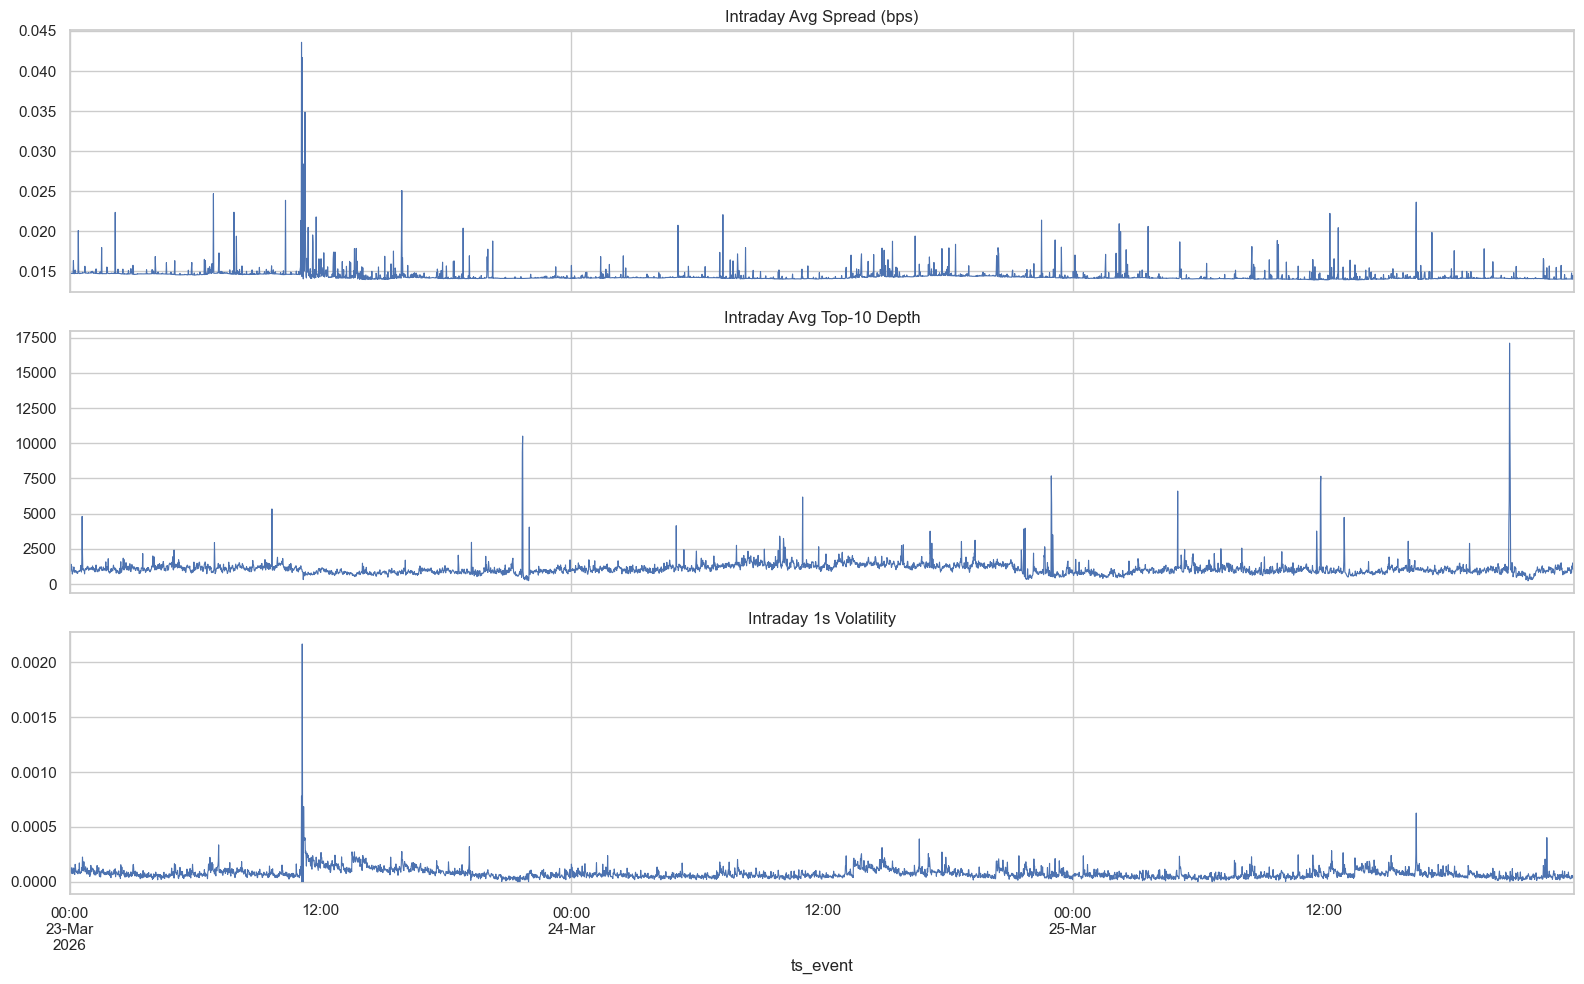

In [29]:
work_df["depth_top10"] = work_df[bid_sz_cols + ask_sz_cols].sum(axis=1)

intraday = work_df.resample("1min").agg(
    avg_spread_bps=("spread_bps", "mean"),
    avg_depth_top10=("depth_top10", "mean"),
    vol_1s=("ret_1s", "std"),
)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
intraday["avg_spread_bps"].plot(ax=axes[0], linewidth=0.8)
axes[0].set_title("Intraday Avg Spread (bps)")

intraday["avg_depth_top10"].plot(ax=axes[1], linewidth=0.8)
axes[1].set_title("Intraday Avg Top-10 Depth")

intraday["vol_1s"].plot(ax=axes[2], linewidth=0.8)
axes[2].set_title("Intraday 1s Volatility")
axes[2].set_xlabel("ts_event")
plt.tight_layout()
plt.show()

## 10) Optional Advanced: Liquidity Shocks & Imbalance Spikes

Почему важно: экстремумы ликвидности и дисбаланса часто совпадают с локальными microstructure events.

In [30]:
# Liquidity shock: large negative change in top-10 depth
work_df["depth_delta"] = work_df["depth_top10"].diff()
shock_thr = work_df["depth_delta"].quantile(0.01)
liq_shocks = work_df.loc[work_df["depth_delta"] <= shock_thr, ["mid_px", "spread_bps", "depth_top10", "depth_delta", "imbalance"]]

# Imbalance spikes
imb_thr = work_df["imbalance"].abs().quantile(0.99)
imb_spikes = work_df.loc[work_df["imbalance"].abs() >= imb_thr, ["mid_px", "spread_bps", "depth_top10", "imbalance", "ret_1s"]]

print("Liquidity shocks (1% tail):", len(liq_shocks), "threshold:", float(shock_thr))
print("Imbalance spikes (99% abs):", len(imb_spikes), "threshold:", float(imb_thr))

display(liq_shocks.head(10))
display(imb_spikes.head(10))

Liquidity shocks (1% tail): 25921 threshold: -871.7060000000001
Imbalance spikes (99% abs): 25921 threshold: 0.9962567180024996


,mid_px,spread_bps,depth_top10,depth_delta,imbalance
ts_event,,,,,
2026-03-23 00:00:00.200000+00:00,67830.85,0.014743,532.76,-1060.34,0.950071
2026-03-23 00:00:04.900000+00:00,67859.95,0.014736,997.19,-1195.28,0.956999
2026-03-23 00:00:06.700000+00:00,67866.65,0.014735,881.63,-1162.99,0.649445
2026-03-23 00:00:08+00:00,67860.05,0.014736,757.65,-1387.00,0.177694
2026-03-23 00:00:18.400000+00:00,67895.75,0.014728,2020.94,-901.07,-0.990925
2026-03-23 00:00:20.500000+00:00,67931.15,0.014721,944.29,-2910.29,0.629139
2026-03-23 00:00:25.100000+00:00,67984.05,0.014709,614.34,-1549.97,0.653124
2026-03-23 00:00:28.400000+00:00,67964.15,0.014714,1201.74,-1115.49,0.605755
2026-03-23 00:00:41+00:00,67927.05,0.014722,957.38,-874.66,0.464601


,mid_px,spread_bps,depth_top10,imbalance,ret_1s
ts_event,,,,,
2026-03-23 00:00:06.600000+00:00,67865.15,0.014735,2044.62,0.999354,0.000050
2026-03-23 00:00:11.400000+00:00,67873.35,0.014733,2455.54,-0.998681,-0.000239
2026-03-23 00:00:21.800000+00:00,67950.65,0.014717,1499.14,0.998893,0.000324
2026-03-23 00:00:23.800000+00:00,67972.75,0.014712,1149.42,0.996659,0.000166
2026-03-23 00:00:44.600000+00:00,67941.45,0.014719,1364.33,0.999223,-0.000124
2026-03-23 00:00:45.300000+00:00,67948.75,0.014717,514.46,-0.998523,-0.000231
2026-03-23 00:00:48.100000+00:00,67931.55,0.014721,1945.71,-0.997358,-0.000084
2026-03-23 00:00:50.200000+00:00,67922.35,0.014723,1469.05,-0.997740,-0.000006
2026-03-23 00:01:00.900000+00:00,67943.45,0.014718,2421.55,0.999794,-0.000019


## HFT-oriented takeaways template

Заполни после выполнения:

- **Execution risk:** как spread/depth меняются по времени суток.
- **Short-horizon alpha hints:** есть ли монотонность imbalance -> future return.
- **Regime dependency:** где стратегия должна переключать параметры (tight/wide spread).
- **Event handling:** как shocks/spikes влияют на риск и sizing.

In [31]:
df.columns

Index(['ts_event', 'inst_id', 'anchor_snapshot_ts', 'reconstruction_mode',
       'mid_px', 'spread_px', 'bid_px_01', 'bid_sz_01', 'bid_px_02',
       'bid_sz_02', 'bid_px_03', 'bid_sz_03', 'bid_px_04', 'bid_sz_04',
       'bid_px_05', 'bid_sz_05', 'bid_px_06', 'bid_sz_06', 'bid_px_07',
       'bid_sz_07', 'bid_px_08', 'bid_sz_08', 'bid_px_09', 'bid_sz_09',
       'bid_px_10', 'bid_sz_10', 'ask_px_01', 'ask_sz_01', 'ask_px_02',
       'ask_sz_02', 'ask_px_03', 'ask_sz_03', 'ask_px_04', 'ask_sz_04',
       'ask_px_05', 'ask_sz_05', 'ask_px_06', 'ask_sz_06', 'ask_px_07',
       'ask_sz_07', 'ask_px_08', 'ask_sz_08', 'ask_px_09', 'ask_sz_09',
       'ask_px_10', 'ask_sz_10'],
      dtype='object')